In [5]:
import sccellfie
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import glasbey

import textwrap

## To avoid warnings
import warnings
warnings.filterwarnings("ignore")

In [6]:
import anndata as ad

In [7]:
sc.settings.figdir = '/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/da-figures/'

In [8]:
adata = sccellfie.io.load_adata(folder='/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie',
                                filename='Honda_tumor_scCellFie'
                               )

/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_tumor_scCellFie.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_tumor_scCellFie_reactions.h5ad was correctly loaded
/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/scCellFie/Honda_tumor_scCellFie_metabolic_tasks.h5ad was correctly loaded


In [9]:
adata

AnnData object with n_obs × n_vars = 72592 × 683
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'adata_name', 'condition', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_counts'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells', 'gene_count_corr'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'l

In [10]:
adata.metabolic_tasks

AnnData object with n_obs × n_vars = 72592 × 189
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'adata_name', 'condition', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_counts'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'normalization', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

## Defining cell types

In [11]:
cell_group = 'cell_annotation_05'

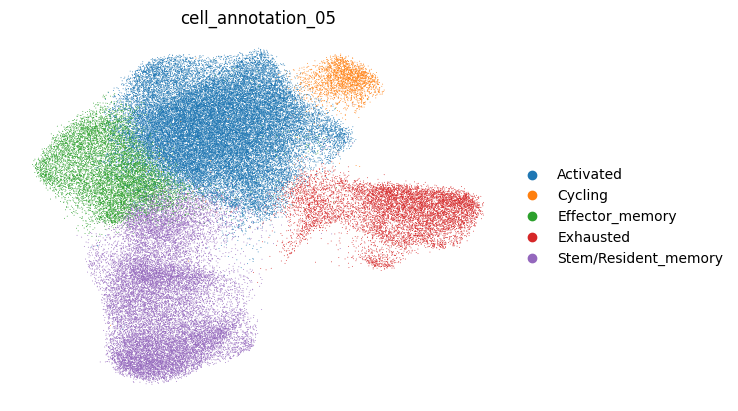

In [12]:
sc.pl.umap(adata, color=cell_group, frameon=False)

## Differential analysis 

### Select conditions to compare

In [13]:
adata.obs.condition.unique() 

['10mix', '11mix', 'GF']
Categories (3, object): ['10mix', '11mix', 'GF']

In [27]:
contrasts = [('11mix', '10mix')]
condition_key = 'condition'

### Filter testable cell types (optional)

In [17]:
control_cells = adata.metabolic_tasks.obs.groupby(['condition', cell_group])['cell_annotation_05'].count().loc['10mix']
effector_cells = adata.metabolic_tasks.obs.groupby(['condition', cell_group])['cell_annotation_05'].count().loc['11mix']

In [18]:
control_cells

cell_annotation_05
Activated               10997
Cycling                   649
Effector_memory          1791
Exhausted                2214
Stem/Resident_memory     6578
Name: cell_annotation_05, dtype: int64

In [19]:
effector_cells

cell_annotation_05
Activated               8553
Cycling                  684
Effector_memory         3241
Exhausted               1741
Stem/Resident_memory    4854
Name: cell_annotation_05, dtype: int64

In [20]:
# Filters
min_n = 50 # Here we do not use a big number as we are only using a subset of the original dataset.
max_log2ratio = 6 # This is 2 power 6 (or 64)

testable_cells = control_cells.index[(control_cells >= min_n) & (effector_cells >= min_n) & (np.log2(control_cells / effector_cells).abs() <= max_log2ratio)].tolist()

In [21]:
testable_cells

['Activated',
 'Cycling',
 'Effector_memory',
 'Exhausted',
 'Stem/Resident_memory']

### Input for metabolic tasks

In [22]:
input_adata = adata.metabolic_tasks[adata.metabolic_tasks.obs['cell_annotation_05'].isin(testable_cells)]

In [23]:
input_adata

View of AnnData object with n_obs × n_vars = 72592 × 189
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'adata_name', 'condition', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_counts'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'normalization', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

### Input for individual reactions

In [24]:
input_adata_reactions = adata.reactions[adata.reactions.obs['cell_annotation_05'].isin(testable_cells)]

In [25]:
input_adata_reactions

View of AnnData object with n_obs × n_vars = 72592 × 623
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'adata_name', 'condition', 'batch_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_counts'
    uns: 'Rxn-Max-Genes', 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'normalization', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

### Perform differential analysis - Metabolic tasks

In [28]:
de_results = sccellfie.stats.scanpy_differential_analysis(input_adata,
                                                          cell_type=None,
                                                          cell_type_key=cell_group,
                                                          condition_key=condition_key,
                                                          min_cells=0, # We do not use this as we already filtered cells before
                                                          condition_pairs=contrasts)

Processing DE analysis: 100%|██████████| 5/5 [00:09<00:00,  1.85s/it]


In [21]:
#de_results.reset_index().to_csv(f'{sc.settings.figdir}/DE-effector-metabolic-tasks.csv')

### Perform differential analysis - Metabolic tasks

In [29]:
de_results_reactions = sccellfie.stats.scanpy_differential_analysis(input_adata_reactions,
                                                          cell_type=None,
                                                          cell_type_key=cell_group,
                                                          condition_key=condition_key,
                                                          min_cells=0, # We do not use this as we already filtered cells before
                                                          condition_pairs=contrasts)

Processing DE analysis: 100%|██████████| 5/5 [00:36<00:00,  7.22s/it]


In [30]:
#de_results_reactions.reset_index().to_csv(f'{sc.settings.figdir}/DE-effector-reactions.csv')

## Results interpretation and visualization

We can use a beeswarm plot, where each row (y-axis) represents the cell types, and the x-axis shows the effect size. Dots are each of the tested features (metabolic tasks), and colored whether they pass both filters, adj. P value and effect size (Cohen’s D here).

In [31]:
cohen_threshold = 0.05 # Min value of absolute Cohen's D.
pval_threshold = 0.01 # Min adj. P value
logfc_threshold = np.log2(1.1) # Min log2FC. Leave it as np.log2(1.) if you do not want to use this filter

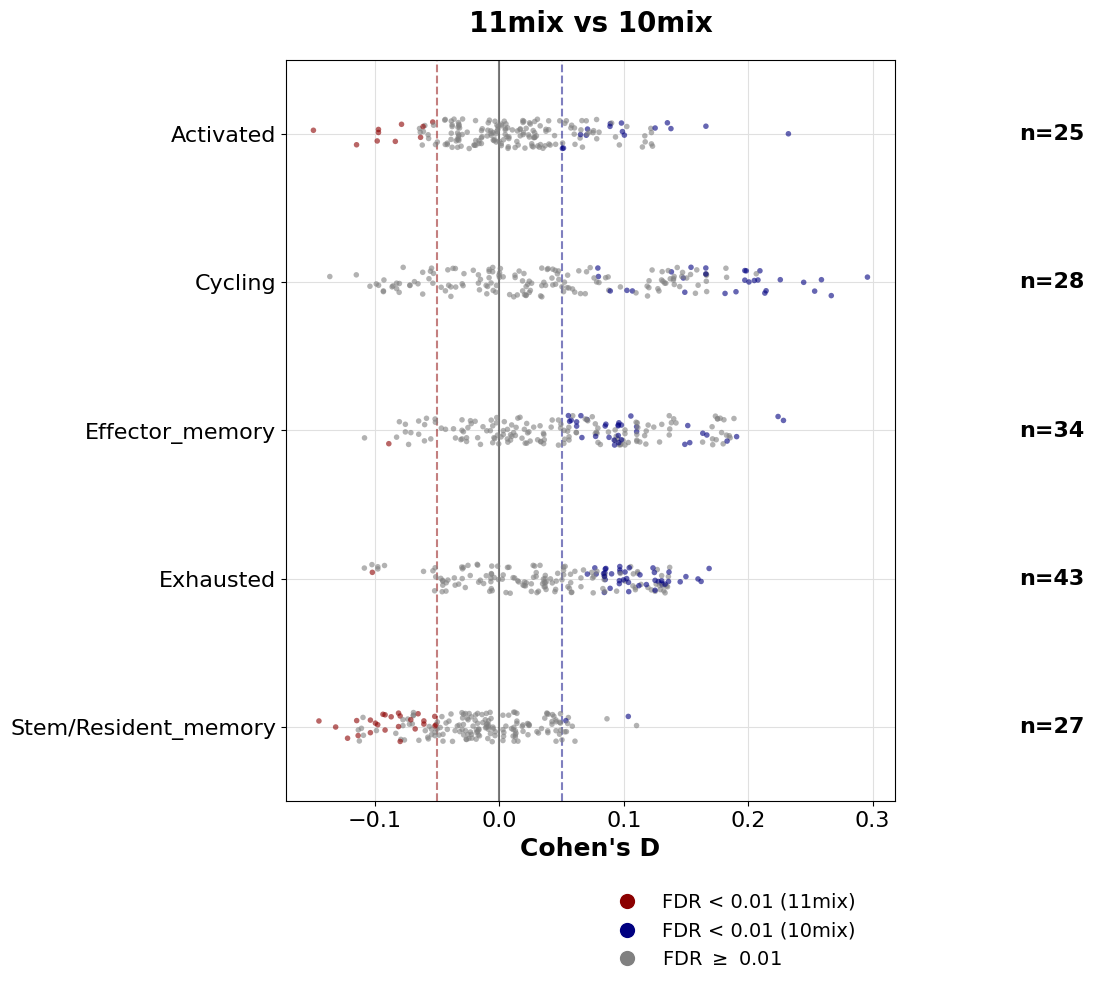

In [32]:
# 1. Update the lambda function to robustly handle labels without prefixes
# If the separator exists, sort by the number; otherwise, sort alphabetically by label name.
sort_lambda = lambda x: pd.Series([
    int(s.split(' | ')[0]) if ' | ' in s else s for s in x
])

fig, ax, sig = sccellfie.plotting.create_beeswarm_plot(
    de_results,
    x='cohens_d',
    cohen_threshold=cohen_threshold,
    pval_threshold=pval_threshold,
    logfc_threshold=logfc_threshold,
    show_n_significant=True, 
    strip_jitter=True,
    sort_lambda=sort_lambda, # Using the safer lambda function
    lgd_bbox_to_anchor=(0.5, -0.1), 
    ticks_fontsize=16,
    labels_fontsize=18,
    figsize=(12, 10)
)

# 2. Force layout generation
fig.canvas.draw()

# 3. Clean up the y-labels cleanly without raising errors
ylabels = [t.get_text() for t in ax.get_yticklabels()]
# Only split if ' | ' is actually present in the text string
cleaned_labels = [label.split(' | ')[1] if ' | ' in label else label for label in ylabels]

# 4. Safely set tick labels back onto the axis
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(cleaned_labels, fontsize=16)
ax.set_ylabel('')

import matplotlib.pyplot as plt
plt.show()


In [33]:
#The number of unique metabolic tasks changing across all cell types:

sig_tasks = sig.reset_index().feature.unique().tolist()
len(sig_tasks)

96

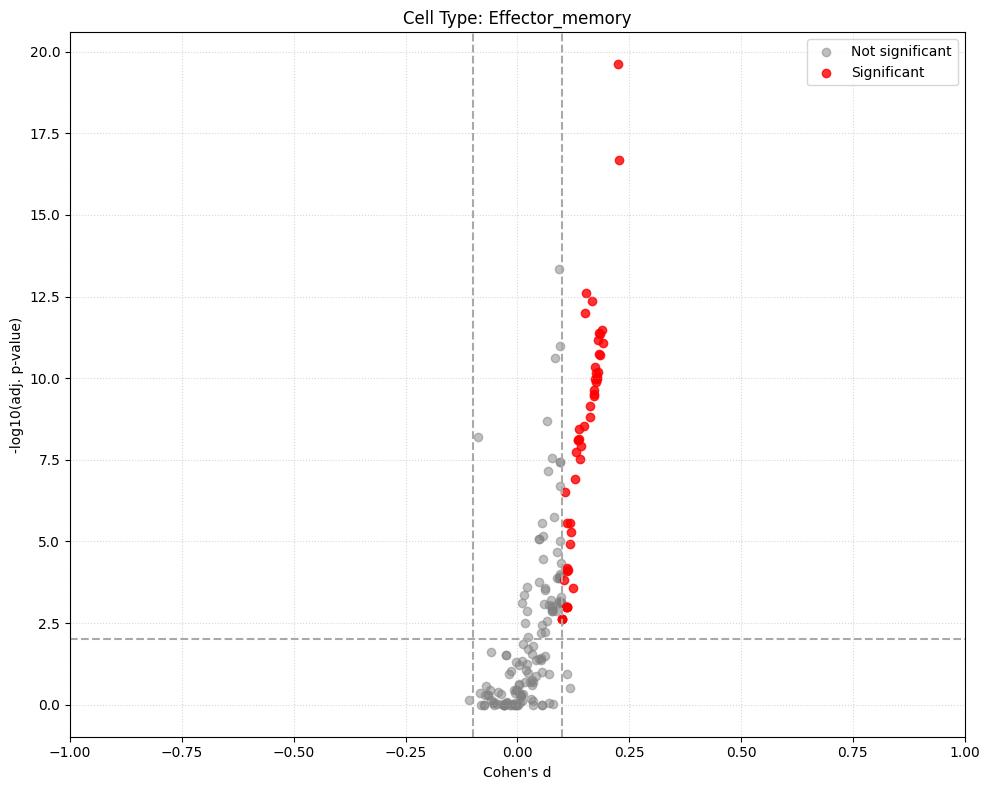

In [34]:
#  volcano plot for one cell type at a time
Effector_tasks = sccellfie.plotting.create_volcano_plot(de_results,
                                                       effect_threshold=0.1,
                                                       padj_threshold=0.01,
                                                       cell_type='Effector_memory',
                                                       group1=None,
                                                       group2=None,
                                                       effect_col='cohens_d',
                                                       effect_title="Cohen's d",
                                                       wrapped_title_length=50,
                                                       save='Overall-VolcanoPlot',
                                                       dpi=300,
                                                       tight_layout=True
                                                      )

In [83]:
Effector_tasks

['Synthesis of ubiquinone from tyrosine',
 'Ornithine degradation',
 'Phenylalanine degradation',
 'Tyrosine degradation',
 'Arginine degradation',
 'Alanine degradation',
 'Synthesis of spermidine from ornithine',
 'Cysteine degradation',
 'Trafficking to endosomes (Clathrin Vesicles)',
 'Glutamate degradation',
 'Proline degradation',
 'Valine degradation',
 'Isoleucine degradation']

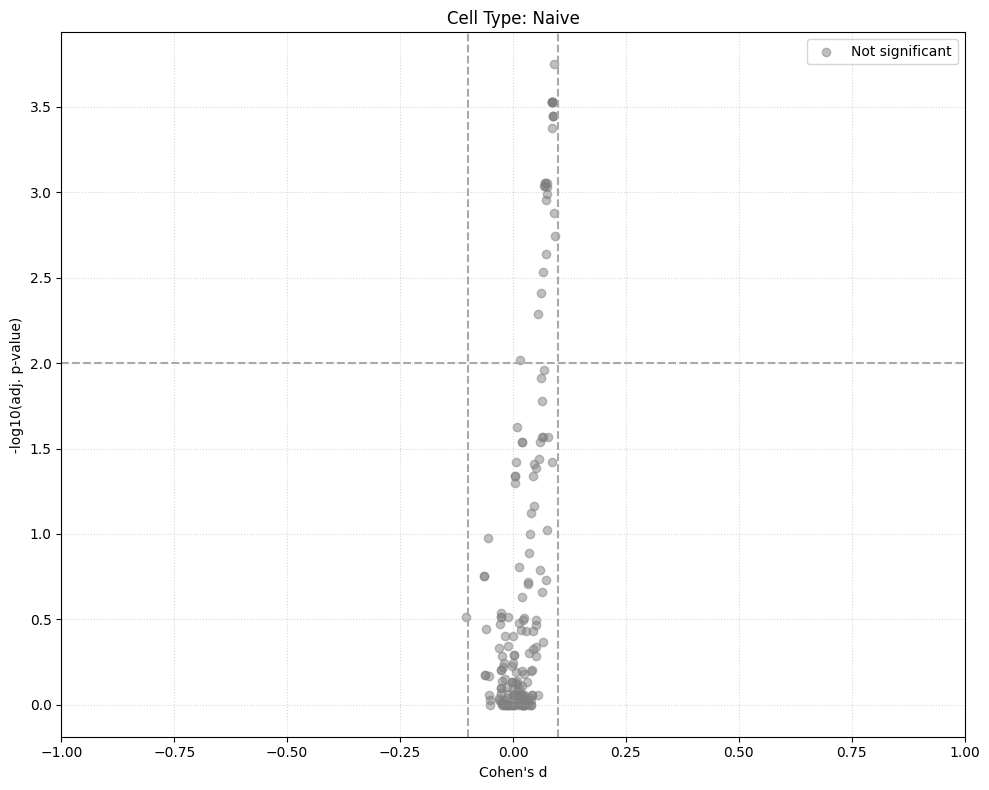

In [101]:
#  volcano plot for one cell type at a time
Naive_tasks = sccellfie.plotting.create_volcano_plot(de_results,
                                                       effect_threshold=0.1,
                                                       padj_threshold=0.01,
                                                       cell_type='Naive',
                                                       group1=None,
                                                       group2=None,
                                                       effect_col='cohens_d',
                                                       effect_title="Cohen's d",
                                                       wrapped_title_length=50,
                                                       save='Overall-VolcanoPlot',
                                                       dpi=300,
                                                       tight_layout=True
                                                      )

In [102]:
Naive_tasks

[]

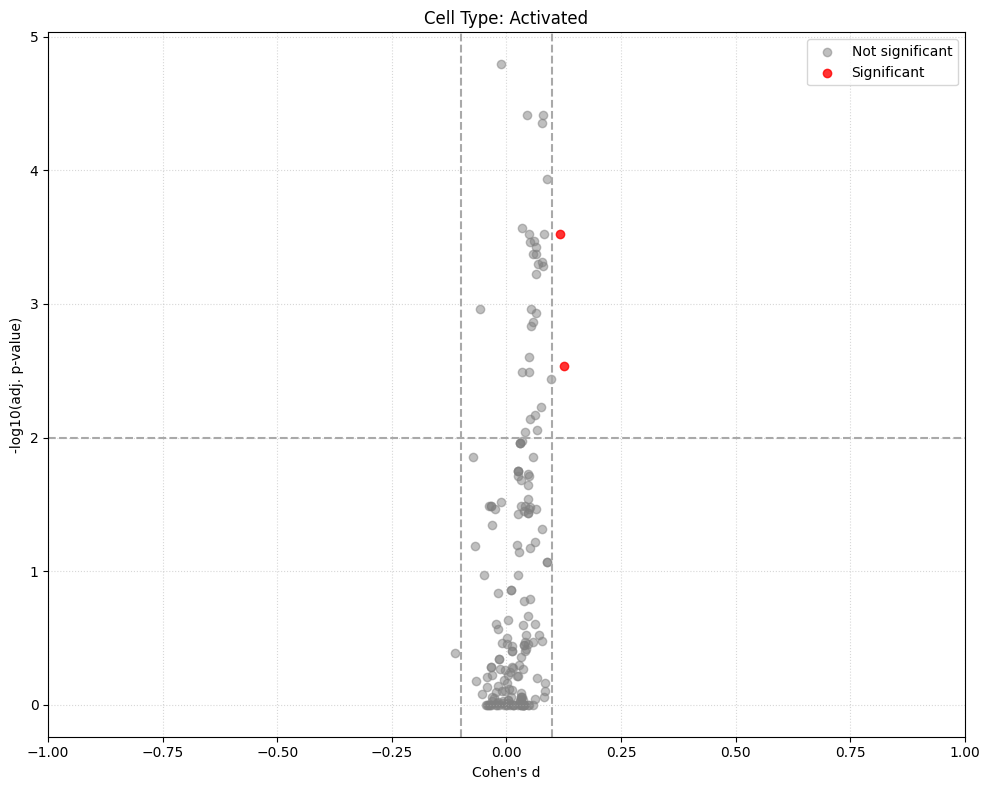

In [103]:
#  volcano plot for one cell type at a time
Activated_tasks = sccellfie.plotting.create_volcano_plot(de_results,
                                                       effect_threshold=0.1,
                                                       padj_threshold=0.01,
                                                       cell_type='Activated',
                                                       group1=None,
                                                       group2=None,
                                                       effect_col='cohens_d',
                                                       effect_title="Cohen's d",
                                                       wrapped_title_length=50,
                                                       save='Overall-VolcanoPlot',
                                                       dpi=300,
                                                       tight_layout=True
                                                      )

In [104]:
Activated_tasks

['Glycine degradation', 'Synthesis of spermidine from ornithine']

## Plot number of major task groups up/down regulated

Number of significant tasks given their major categories located in sccellfie_db['task_info']

sccellfie_db = sccellfie.datasets.load_sccellfie_database(organism='mouse')

In [35]:
def plot_single(condition, ax, pathway, sig_data):
    pathway_counts = {'System': pd.DataFrame(), 'Subsystem': pd.DataFrame()}

    for c, df in sig_data.reset_index().groupby('cell_type'):
        for k, v in pathway_counts.items():
            df2 = df.set_index('feature').join(sccellfie_db['task_info'].set_index('Task'), how='inner')
            df2 = df2.loc[df2.log2FC > 0] if condition == 'up' else df2.loc[df2.log2FC < 0]
            df2 = df2.value_counts(k).to_frame().reset_index()
            df2['cell_type'] = c
            df2 = df2[['cell_type', k, 'count']]
            df2[k] = df2[k].apply(lambda x: x.upper())
            pathway_counts[k] = pd.concat([pathway_counts[k], df2])

    df = pathway_counts[pathway].sort_values('count')
    totals = df.groupby('cell_type')['count'].sum()

    df_normalized = df.copy()
    df_normalized['fraction'] = df.groupby('cell_type')['count'].transform(lambda x: x / x.sum())
    pivoted_data = df_normalized.pivot(index='cell_type', columns=pathway, values='fraction')
    pivoted_data = pivoted_data.sort_index().fillna(0.)

    n_systems = len(pivoted_data.columns)
    colors = glasbey.extend_palette('Set2', palette_size=max([n_systems, 10]))

    pivoted_data.plot(kind='barh', stacked=True, ax=ax, color=colors, legend=False)
    ax.set_xlim((0, 1))
    ax.invert_yaxis()

    ylabels = ax.get_yticklabels()
    ax.tick_params(axis='both', which='major', labelsize=12)

    for idx, cell_type in enumerate(pivoted_data.index):
        ax.text(1.02, idx, f'n={totals[cell_type]:,}', va='center', fontsize=12)

    ax.set_xlabel('Fraction', fontsize=14)
    ax.set_ylabel('')

    return pivoted_data.columns, colors

In [36]:
sig

index  \
cell_type            feature                                                     
Activated            Retro-translocation & substrate ubiquitination        437   
                     Valine to succinyl-coA                                432   
                     Fructose degradation (to glucose-3-phosphate)         397   
                     Krebs cycle - NADH generation                         393   
                     Cysteine synthesis (need serine and methionine)       390   
...                                                                        ...   
Stem/Resident_memory Co-translational translocation                        734   
                     Branching (N-acetylglucosaminyltransferases)          743   
                     Starch degradation                                    754   
                     Synthesis of fructose-6-phosphate from erythros...    702   
                     Degradation of guanine to urate                       699   

                                                                        group1  \
cell_type            feature                                                     
Activated            Retro-translocation & substrate ubiquitination      11mix   
                     Valine to succinyl-coA                              11mix   
                     Fructose degradation (to glucose-3-phosphate)       11mix   
                     Krebs cycle - NADH generation                       11mix   
                     Cysteine synthesis (need serine and methionine)     11mix   
...                                                                        ...   
Stem/Resident_memory Co-translational translocation                      11mix   
                     Branching (N-acetylglucosaminyltransferases)        11mix   
                     Starch degradation                                  11mix   
                     Synthesis of fructose-6-phosphate from erythros...  11mix   
                     Degradation of guanine to urate                     11mix   

                                                                        group2  \
cell_type            feature                                                     
Activated            Retro-translocation & substrate ubiquitination      10mix   
                     Valine to succinyl-coA                              10mix   
                     Fructose degradation (to glucose-3-phosphate)       10mix   
                     Krebs cycle - NADH generation                       10mix   
                     Cysteine synthesis (need serine and methionine)     10mix   
...                                                                        ...   
Stem/Resident_memory Co-translational translocation                      10mix   
                     Branching (N-acetylglucosaminyltransferases)        10mix   
                     Starch degradation                                  10mix   
                     Synthesis of fructose-6-phosphate from erythros...  10mix   
                     Degradation of guanine to urate                     10mix   

                                                                           log2FC  \
cell_type            feature                                                        
Activated            Retro-translocation & substrate ubiquitination      0.346437   
                     Valine to succinyl-coA                              0.239354   
                     Fructose degradation (to glucose-3-phosphate)       0.261289   
                     Krebs cycle - NADH generation                       0.187277   
                     Cysteine synthesis (need serine and methionine)     0.416381   
...                                                                           ...   
Stem/Resident_memory Co-translational translocation                     -0.189734   
                     Branching (N-acetylglucosaminyltransferases)       -0.238555   
                     S

In [38]:
sccellfie_db = sccellfie.datasets.load_sccellfie_database(organism='mouse')

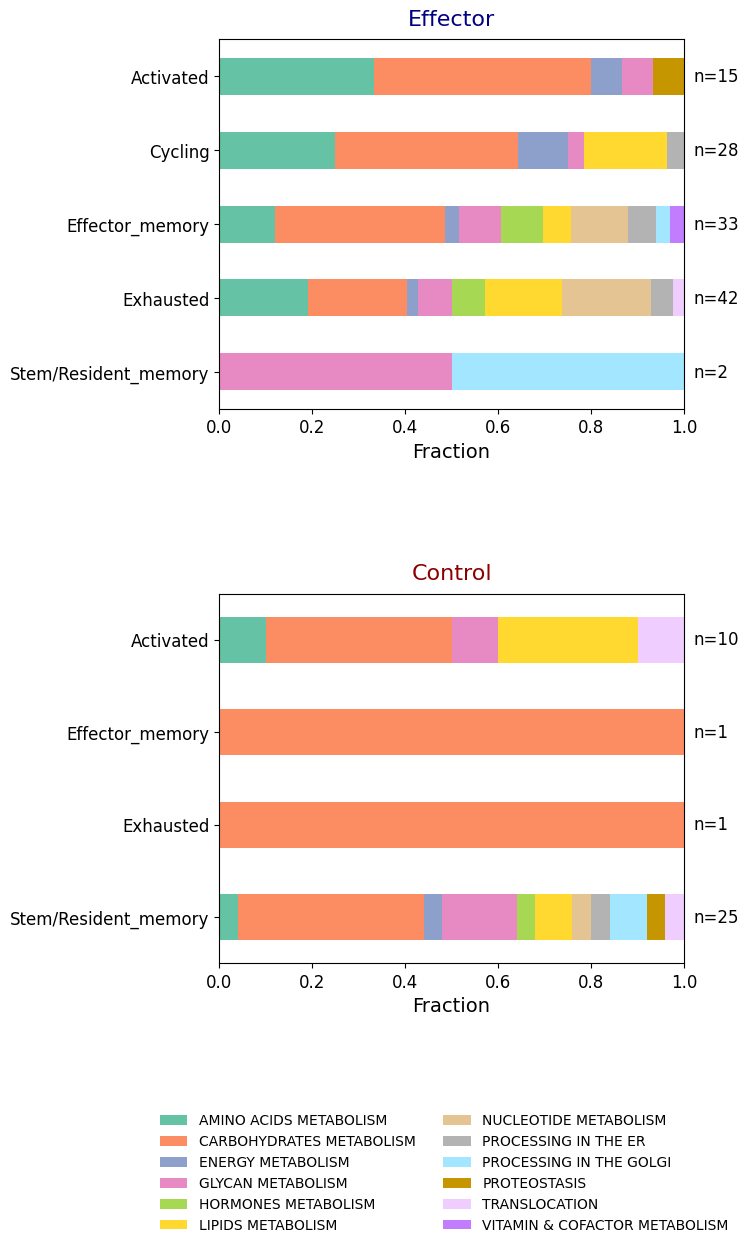

In [39]:
from matplotlib.colors import to_rgb

pathway = 'System'
condition1_color='#8B0000'
condition2_color='#000080'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 12), height_ratios=[1, 1])

legend_elements, colors = plot_single('up', ax1, pathway, sig)
plot_single('down', ax2, pathway, sig)

ax1.set_title('Effector', fontsize=16, pad=10, color=to_rgb(condition2_color))
ax2.set_title('Control', fontsize=16, pad=10, color=to_rgb(condition1_color))

plt.figlegend(labels=legend_elements,
              bbox_to_anchor=(0.5, -0.005),
              ncols=2 if pathway == 'System' else 2,
              frameon=False,
              loc='upper center')

plt.subplots_adjust(hspace=0.5)
# For saving this figure, uncomment the code below
# plt.savefig(f'{sc.settings.figdir}./scCellFie-DA-{pathway}-Combined.pdf',
#             dpi=300,
#             bbox_inches='tight')

## Visualize changes in distributions across single cells

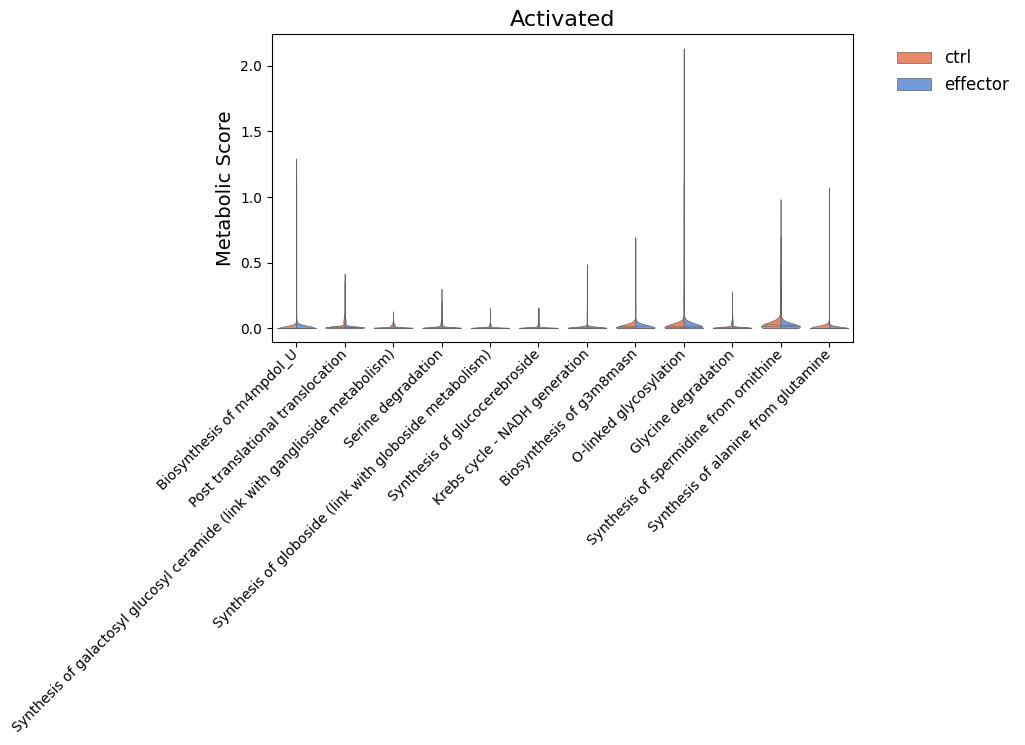

In [58]:
import matplotlib.pyplot as plt

cell_show = ['Activated']

for c in cell_show:
    sig_features = [idx for idx in sig.loc[c].sort_values('log2FC').index]
    N = len(sig_features)
    if N > 0:
        width = min([18, 1.5 + 0.5 * N])
        fig, ax = sccellfie.plotting.create_comparative_violin(
            adata=adata.metabolic_tasks,
            significant_features=sig_features,
            group1='ctrl',
            group2='effector',
            condition_key=condition_key,
            cell_type_key=cell_group,
            celltype=c,
            xlabel='',
            ylabel='Metabolic Score',
            palette=['coral', 'cornflowerblue'],
            wrapped_title_length=100,
            figsize=(width, 4),
            fontsize=14,
            title=c,
            tight_layout=False,
            # save=f'DE-Dist-{cname}'
        )
        
        # --- Rotate x-axis labels 45 degrees ---
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Ensure rotated labels don't get cut off at the bottom
        fig.tight_layout()
        
        plt.show()

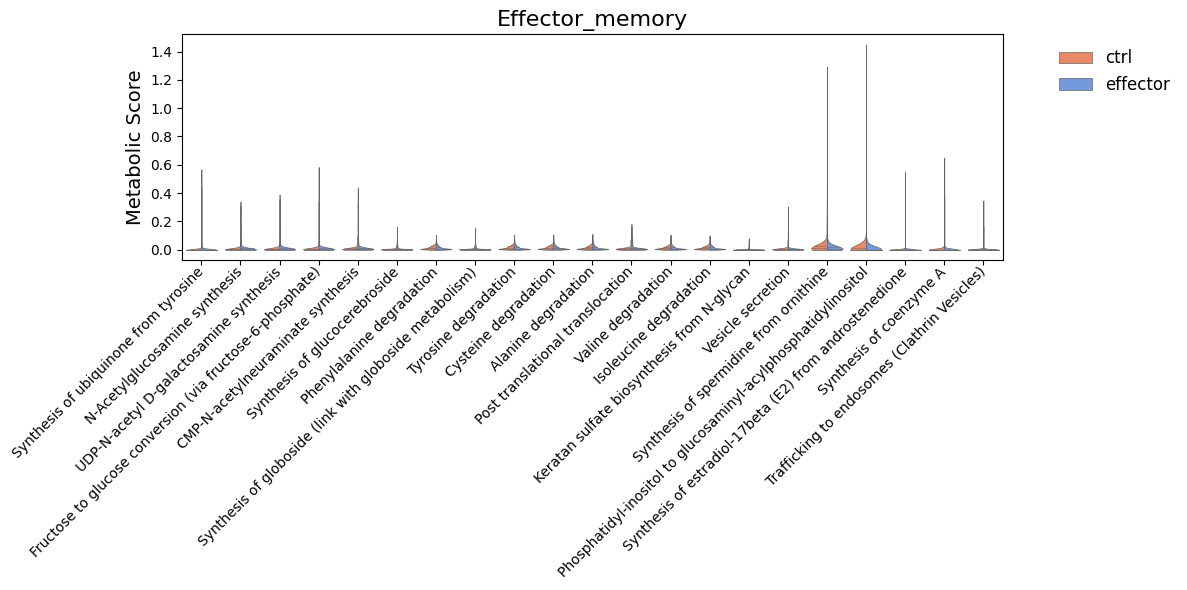

In [63]:
import matplotlib.pyplot as plt

cell_show = ['Effector_memory']

for c in cell_show:
    sig_features = [idx for idx in sig.loc[c].sort_values('log2FC').index]
    N = len(sig_features)
    if N > 0:
        width = min([18, 1.5 + 0.5 * N])
        fig, ax = sccellfie.plotting.create_comparative_violin(
            adata=adata.metabolic_tasks,
            significant_features=sig_features,
            group1='ctrl',
            group2='effector',
            condition_key=condition_key,
            cell_type_key=cell_group,
            celltype=c,
            xlabel='',
            ylabel='Metabolic Score',
            palette=['coral', 'cornflowerblue'],
            wrapped_title_length=100,
            figsize=(width, 6),
            fontsize=14,
            title=c,
            tight_layout=False,
            # save=f'DE-Dist-{cname}'
        )
        
        # --- Rotate x-axis labels 45 degrees ---
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Ensure rotated labels don't get cut off at the bottom
        fig.tight_layout()
        
        plt.show()

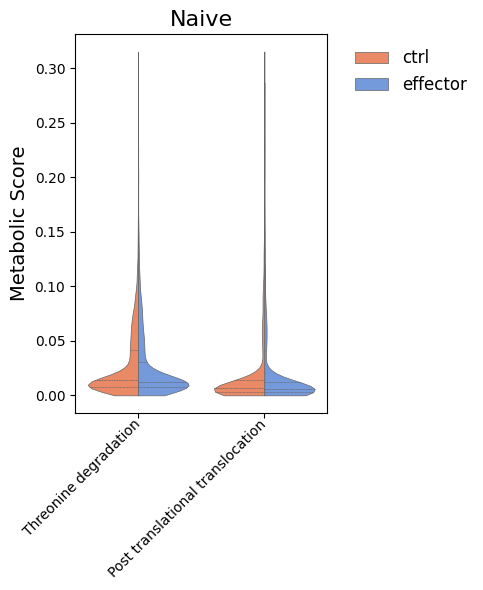

In [66]:
import matplotlib.pyplot as plt

cell_show = ['Naive']

for c in cell_show:
    sig_features = [idx for idx in sig.loc[c].sort_values('log2FC').index]
    N = len(sig_features)
    if N > 0:
        width = min([18, 1.5 + 0.5 * N])
        fig, ax = sccellfie.plotting.create_comparative_violin(
            adata=adata.metabolic_tasks,
            significant_features=sig_features,
            group1='ctrl',
            group2='effector',
            condition_key=condition_key,
            cell_type_key=cell_group,
            celltype=c,
            xlabel='',
            ylabel='Metabolic Score',
            palette=['coral', 'cornflowerblue'],
            wrapped_title_length=100,
            figsize=(5, 6),
            fontsize=14,
            title=c,
            tight_layout=False,
            # save=f'DE-Dist-{cname}'
        )
        
        # --- Rotate x-axis labels 45 degrees ---
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Ensure rotated labels don't get cut off at the bottom
        fig.tight_layout()
        
        plt.show()

## Differential analysis - using all single cells.

In [40]:
da_all = sccellfie.stats.pairwise_differential_analysis(adata.metabolic_tasks,
                                                        groupby='condition', # Column including the conditions
                                                        var_names=None,
                                                        order=None,
                                                        alternative='two-sided',
                                                        alpha=0.05)

Processing features: 100%|██████████| 189/189 [00:02<00:00, 80.51it/s]


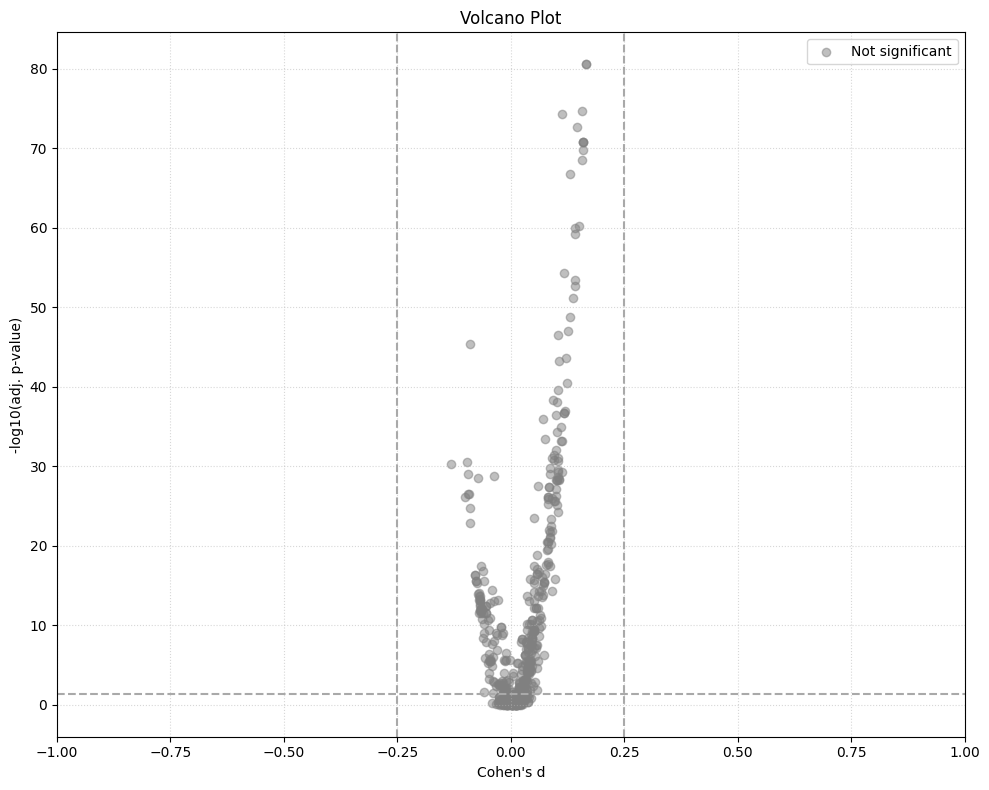

In [43]:
overall_tasks = sccellfie.plotting.create_volcano_plot(da_all,
                                                       effect_threshold=0.25,
                                                       padj_threshold=0.05,
                                                       cell_type=None,
                                                       group1=None,
                                                       group2=None,
                                                       effect_col='cohens_d',
                                                       effect_title="Cohen's d",
                                                       wrapped_title_length=50,
                                                       save='Overall-VolcanoPlot',
                                                       dpi=300,
                                                       tight_layout=True
                                                      )

In [42]:
overall_tasks

[]